# import library

In [1]:
# --- parameters ---
# If you use papermill, it can override TEST_LIMIT via -p TEST_LIMIT <N>
TEST_LIMIT = 0                 # 0 = all songs; otherwise cap to N
PRE_ROOT   = "/data/pre_processed_data"

In [2]:
# ==== SAFE TEST CONFIG (add this cell) ====
from pathlib import Path
import pickle, glob, numpy as np

PRE_ROOT = Path("/data/pre_processed_data")  # your real location
SAFE_TEST = True          # allows running with only step_2 outputs present
TEST_LIMIT = 20           # 0 = all songs; else process at most N songs

with open(PRE_ROOT / "model_out_drum_ssm_pkg.pkl", "rb") as f:
    _pkg = pickle.load(f)          # [n_bars_list, cqt_ssm_list, drum_ssm_list, drum_model_ssm_list]
_n_bars = _pkg[0]
N_SONGS_FULL = len(_n_bars)

try:
    _lim = int(TEST_LIMIT)
except Exception:
    _lim = 0
N_SONGS = N_SONGS_FULL if _lim == 0 else min(_lim, N_SONGS_FULL)
print(f"[boot] N_SONGS={N_SONGS}/{N_SONGS_FULL}")

[boot] N_SONGS=20/12321


In [3]:
#With generated drum SSM in step 2, bar seelction mechanism is now applied on melodic track spectrogram to select most relevant bars for drum track generation

import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

import librosa, IPython, datetime, time, os, sys, copy, pickle, glob
import numpy as np
import pandas as pd
import IPython.display as ipd
from scipy.spatial.distance import euclidean, pdist, squareform
from scipy.stats import norm as stats_norm
from time import gmtime, strftime
from imageio import imread as imread
from imageio import imsave as imsave
import cv2
import librosa.display
from matplotlib import pyplot as plt
import pretty_midi
from midiutil.MidiFile import MIDIFile

import matplotlib.pyplot as plt
%matplotlib inline

print ("[info] Current Time:     " + datetime.datetime.now().strftime('%Y/%m/%d  %H:%M:%S'))
print ("[info] Python Version:   " + sys.version.split('\n')[0].split(' ')[0])
print ("[info] Working Dir:      " + os.getcwd()+'/')

[info] Current Time:     2025/08/28  07:37:28
[info] Python Version:   3.11.13
[info] Working Dir:      /workspace/


# Define SSM function

In [4]:
# def rsssm_762(rf7_input_figure):
    
#     save_data = rf7_input_figure;     save_file_name = './saving_tmp_file_vae1.png';
#     fig = plt.figure(figsize=[8,8]);     ax = fig.add_subplot(111);
#     ax.imshow(save_data,
#               origin='lower', 
#               cmap='hot')
#     ax.axes.get_xaxis().set_visible(False);     ax.axes.get_yaxis().set_visible(False); ax.set_frame_on(False);
#     plt.savefig(save_file_name,
#                 dpi=80,
#                 bbox_inches='tight',
#                 pad_inches=0)
#     #plt.show()
#     plt.close()
#     #IPython.display.clear_output()
#     img_readback = cv2.imread(save_file_name)
#     os.remove(save_file_name)
#     img_readback = np.mean(img_readback, axis=-1)
#     return(-img_readback)

def rsssm_762(rf7_input_figure):
    """
    Render an SSM-like array with the 'hot' colormap and return a
    grayscale image (negated), as in the original — but robust to
    (1, H, W) or (H, W, 1) inputs from the PyTorch path.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os

    # --- normalize input to 2-D (H, W) ---
    x = rf7_input_figure
    # accept torch tensors transparently
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    x = np.asarray(x)
    # drop leading channel=1 or trailing channel=1
    if x.ndim == 3 and x.shape[0] == 1:
        x = x[0]
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]
    if x.ndim != 2:
        raise ValueError(f"rsssm_762 expects 2-D after squeeze, got {x.shape}")

    save_data = x
    save_file_name = './saving_tmp_file_vae1.png'

    # --- render with matplotlib (same as your original) ---
    fig = plt.figure(figsize=[8, 8])
    ax = fig.add_subplot(111)
    ax.imshow(save_data, origin='lower', cmap='hot')
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)
    ax.set_frame_on(False)
    plt.savefig(save_file_name, dpi=80, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    # --- read back and convert to grayscale; keep your negative sign ---
    img_readback = None
    try:
        import cv2
    except Exception:
        cv2 = None

    try:
        if cv2 is not None:
            img_readback = cv2.imread(save_file_name)
        else:
            # fallback if cv2 isn't available
            import imageio.v2 as imageio
            img_readback = imageio.imread(save_file_name)
    finally:
        try:
            os.remove(save_file_name)
        except Exception:
            pass

    # to grayscale
    if img_readback.ndim == 3:
        img_readback = np.mean(img_readback, axis=-1)

    return -img_readback

# Define function to read CQT data

In [5]:
read_pooled_cqt_flist = np.sort(glob.glob('/data/pre_processed_data/cqt_pooled_data/*.pkl', recursive=True)).tolist()

print ('Total files: {}'.format(len(read_pooled_cqt_flist)))
for x in read_pooled_cqt_flist[:3]: print (x)

def read_pooled_cqt(file_idx,
                    read_pooled_cqt_flist=read_pooled_cqt_flist):
    
    file_name = read_pooled_cqt_flist[file_idx]
    with open(file_name, 'rb') as pkl_file:
        pooled_cqt_data = pickle.load(pkl_file)
        
    return (pooled_cqt_data)

# print(len(read_pooled_cqt(0)))
# print(read_pooled_cqt(0)[0].shape)

# Build abs_bar_idx_str_list only from n_bars_list (no dependency on pooled CQT)

Total files: 0


# Reload 46-inst drum MIDI data

In [6]:
# file_name = 'song_drum_bar_list_46.pkl'
# folder_name = '/data/pre_processed_data/cdsed_drum_bar_list_28_46/'
# full_file_name = folder_name + file_name
    
# with open(full_file_name, 'rb') as pkl_file:
#     song_drum_bar_list_46 = pickle.load(pkl_file)

# song_idx = 0; bar_idx = 0;
# total_songs = len(song_drum_bar_list_46)

# print('[info] Songs reloaded: {}'.format(total_songs))
# #print(song_drum_bar_list_46[song_idx][bar_idx].shape)

# preview load (non-fatal if missing) + define total_songs regardless

file_name = '/data/pre_processed_data/cdsed_drum_bar_list_28_46/song_drum_bar_list_46.pkl'
try:
    with open(file_name, 'rb') as pkl_file:
        song_drum_bar_list_46 = pickle.load(pkl_file)
    total_songs = len(song_drum_bar_list_46)
    print('[info] Songs reloaded:', total_songs)
except FileNotFoundError:
    print(f"[warn] {file_name} not found; continuing without it (attributes will use defaults).")
    song_drum_bar_list_46 = None
    # derive total_songs from step_2 package so later cells work
    with open('/data/pre_processed_data/model_out_drum_ssm_pkg.pkl','rb') as f:
        _pkg = pickle.load(f)  # [n_bars_list, cqt, drum_gt, drum_pred]
    total_songs = len(_pkg[0])
    print('[info] total_songs (from step_2):', total_songs)

# Define pooled-CQT reader, but do NOT call it (folder may be empty during partial runs)
read_pooled_cqt_flist = np.sort(glob.glob('/data/pre_processed_data/cqt_pooled_data/*.pkl', recursive=True)).tolist()
def read_pooled_cqt(file_idx, read_pooled_cqt_flist=read_pooled_cqt_flist):
    file_name = read_pooled_cqt_flist[file_idx]
    with open(file_name, 'rb') as pkl_file:
        pooled_cqt_data = pickle.load(pkl_file)
    return pooled_cqt_data
# (no demo prints here)

[warn] /data/pre_processed_data/cdsed_drum_bar_list_28_46/song_drum_bar_list_46.pkl not found; continuing without it (attributes will use defaults).


[info] total_songs (from step_2): 12321


# Get bar index

In [7]:
# bar_num_list1 = []; bar_num_list2 = [];

# for song_idx in range(0, total_songs):
    
#     bar_num_list1.append(len(song_drum_bar_list_46[song_idx]))
#     bar_num_list2.append(len(read_pooled_cqt(song_idx)))
    

# # Get absolute bar index
# abs_bar_idx_str_list = []

# for song_idx in range(0, total_songs):
    
#     song_idx_str = "{:0>5}".format(song_idx)
    
#     total_bars = len(song_drum_bar_list_46[song_idx])
    
#     for bar_idx in range(0, total_bars):
        
#         bar_idx_str = "{:0>3}".format(bar_idx)
        
#         abs_bar_idx_str = song_idx_str + "_" + bar_idx_str
        
#         abs_bar_idx_str_list.append(abs_bar_idx_str)


# # save abs_bar_idx_list
# with open('/data/pre_processed_data/model_out_drum_ssm_pkg.pkl', 'rb') as pkl_file:
#     pickle.dump(abs_bar_idx_str_list, pkl_file)
    
# print('[info] bar index info reloaded.')

# Get bar num list + absolute bar index list (safe, minimal change)
from pathlib import Path
import pickle

PRE = Path("/data/pre_processed_data")

# step_2 saved [n_bars_list, cqt_ssm_list, drum_ssm_list, drum_model_ssm_list]
with open(PRE/"model_out_drum_ssm_pkg.pkl", "rb") as f:
    _pkg = pickle.load(f)
n_bars_list = [int(x) for x in _pkg[0]]

# Define total_songs exactly once, honoring N_SONGS/TEST_LIMIT if you set them earlier
N_FULL = len(n_bars_list)
total_songs = N_FULL
if 'N_SONGS' in globals():
    total_songs = int(N_SONGS)

# Bar-count lists (keep the original variable names)
bar_num_list1 = n_bars_list[:total_songs]
bar_num_list2 = n_bars_list[:total_songs]  # pooled CQT may be absent; mirror counts

# Build absolute bar index list: "SSSSS_BBB"
abs_bar_idx_str_list = [
    f"{s:05d}_{b:03d}"
    for s in range(total_songs)
    for b in range(int(n_bars_list[s]))
]

# Save abs_bar_idx_str_list where step_4 expects it (DO NOT write into model_out_drum_ssm_pkg.pkl)
with open(PRE/"abs_bar_idx_str_list.pkl", "wb") as pkl_file:
    pickle.dump(abs_bar_idx_str_list, pkl_file, protocol=pickle.HIGHEST_PROTOCOL)

print(f"[info] total_songs={total_songs} | abs_bar_idx entries={len(abs_bar_idx_str_list)}")

[info] total_songs=20 | abs_bar_idx entries=5120


# Get spectrogram by index

In [8]:
# def get_cqt_by_abs_bar_idx(abs_bar_idx):
    
#     song_idx_int = int(abs_bar_idx.split("_")[0])
#     bar_idx_int = int(abs_bar_idx.split("_")[1])
    
#     reload_cqt_data = read_pooled_cqt(song_idx_int)[bar_idx_int]
#     reload_drum_data = song_drum_bar_list_46[song_idx][bar_idx]
    
#     return (reload_cqt_data, reload_drum_data)

# cqt_data, drum_data = get_cqt_by_abs_bar_idx(abs_bar_idx_str_list[0])
# print(cqt_data.shape)
# print(drum_data.shape)

# Safe preview for per-bar CQT + drum (skip if inputs are missing)
def get_cqt_by_abs_bar_idx(abs_bar_idx):
    song_idx_int = int(abs_bar_idx.split("_")[0])
    bar_idx_int  = int(abs_bar_idx.split("_")[1])

    if not read_pooled_cqt_flist:
        raise RuntimeError("pooled CQT folder is empty; skipping preview")
    if 'song_drum_bar_list_46' not in globals() or song_drum_bar_list_46 is None:
        raise RuntimeError("song_drum_bar_list_46 is missing; skipping preview")

    reload_cqt_data  = read_pooled_cqt(song_idx_int)[bar_idx_int]
    reload_drum_data = song_drum_bar_list_46[song_idx_int][bar_idx_int]
    return reload_cqt_data, reload_drum_data

# Only run the preview if the inputs exist
try:
    if read_pooled_cqt_flist and ('song_drum_bar_list_46' in globals()) and (song_drum_bar_list_46 is not None):
        cqt_data, drum_data = get_cqt_by_abs_bar_idx(abs_bar_idx_str_list[0])
        print(cqt_data.shape)
        print(drum_data.shape)
    else:
        print("[warn] pooled CQT or drum-bar list missing; skipping preview.")
except Exception as e:
    print("[warn] preview skipped:", e)

[warn] pooled CQT or drum-bar list missing; skipping preview.


# Reload SSM data

[cfg] Using 20/12321 songs for test.
[info] abs_bar_idx_str_list saved with 5120 entries.
[info] Song index: 1
[info] SSM shape: (256, 256)


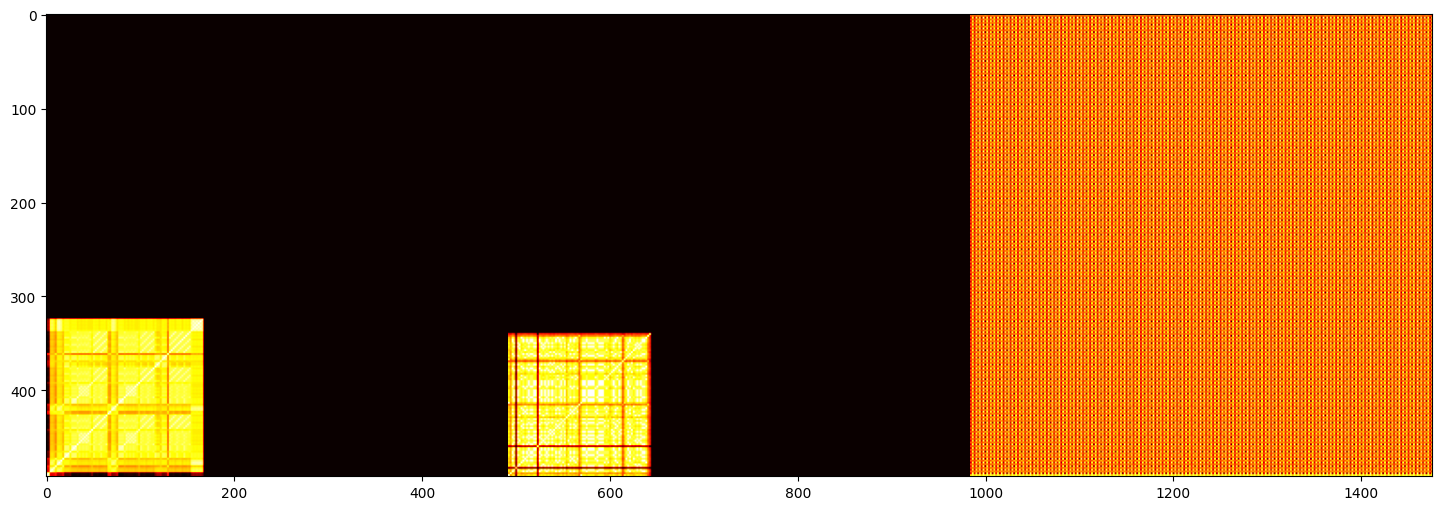

In [9]:
# load 24 test files SSM
with open('/data/pre_processed_data/model_out_drum_ssm_pkg.pkl', 'rb') as pkl_file:
    ssm_data_pkg_list = pickle.load(pkl_file)
    n_bars_list          = ssm_data_pkg_list[0]
    drum_model_ssm_list  = ssm_data_pkg_list[3]    # <-- predicted drum SSMs
    if 'TEST_LIMIT' not in globals():
        TEST_LIMIT = 0  # 0 = use all songs
    N_SONGS_FULL = len(n_bars_list)
    try:
        _lim = int(TEST_LIMIT)
    except Exception:
        _lim = 0
    N_SONGS = N_SONGS_FULL if _lim == 0 else min(_lim, N_SONGS_FULL)
    print(f"[cfg] Using {N_SONGS}/{N_SONGS_FULL} songs for test.")

abs_bar_idx_str_list = []
for s in range(N_SONGS):
    song_len = int(n_bars_list[s])
    for b in range(song_len):
        abs_bar_idx_str_list.append(f"{s:05d}_{b:03d}")

with open('/data/pre_processed_data/abs_bar_idx_str_list.pkl', 'wb') as pkl_file:
    pickle.dump(abs_bar_idx_str_list, pkl_file, protocol=pickle.HIGHEST_PROTOCOL)

print(f"[info] abs_bar_idx_str_list saved with {len(abs_bar_idx_str_list)} entries.")
    
song_idx = 1

song_bars_num =  ssm_data_pkg_list[0][song_idx]
cqt_ssm =        ssm_data_pkg_list[1][song_idx]
drum_ssm =       ssm_data_pkg_list[2][song_idx]
drum_model_ssm = ssm_data_pkg_list[3][song_idx]

print ('[info] Song index: {}'.format(song_idx))
print ('[info] SSM shape: {}'.format(drum_model_ssm.shape))

merged_plot_data = np.hstack([rsssm_762(cqt_ssm), 
                              rsssm_762(drum_ssm), 
                              rsssm_762(drum_model_ssm)])
plt.figure(figsize=(6*3, 6)); plt.imshow(merged_plot_data, cmap='hot'); plt.show();

# Check original drum SSM value range

In [10]:
data_avg_v_list = []; data_std_v_list = []; data_max_v_list = []; data_min_v_list = [];

tota_files = len(ssm_data_pkg_list[0])

for song_idx in range(0, tota_files):

    drum_ssm_data = ssm_data_pkg_list[3][song_idx]
    
    #print (drum_ssm_data.shape)
    
    data_avg_v_list.append(np.mean(drum_ssm_data))
    data_std_v_list.append(np.std(drum_ssm_data))
    data_max_v_list.append(np.max(drum_ssm_data))
    data_min_v_list.append(np.min(drum_ssm_data))
    
print ('[info] All {} files processed.'.format(tota_files))
print("[info] pix value avg: {:.5f}".format(np.mean(data_avg_v_list)))
print("[info] pix value std: {:.5f}".format(np.mean(data_std_v_list)))
print("[info] pix value max: {:.5f}".format(np.max(data_max_v_list)))
print("[info] pix value min: {:.5f}".format(np.min(data_min_v_list)))

[info] All 12321 files processed.
[info] pix value avg: 0.51604
[info] pix value std: 0.00562
[info] pix value max: 0.52601
[info] pix value min: 0.50598


# Check VAE-GAN generated drum SSM value range

In [11]:
data_avg_v_list = []; data_std_v_list = []; data_max_v_list = []; data_min_v_list = [];

tota_files = len(ssm_data_pkg_list[0])

for song_idx in range(0, tota_files):

    drum_ssm_data = ssm_data_pkg_list[3][song_idx]
    
    data_avg_v_list.append(np.mean(drum_ssm_data))
    data_std_v_list.append(np.std(drum_ssm_data))
    data_max_v_list.append(np.max(drum_ssm_data))
    data_min_v_list.append(np.min(drum_ssm_data))
    
print ('[info] All {} files processed.'.format(tota_files))
print("[info] pix value avg: {:.5f}".format(np.mean(data_avg_v_list)))
print("[info] pix value std: {:.5f}".format(np.mean(data_std_v_list)))
print("[info] pix value max: {:.5f}".format(np.max(data_max_v_list)))
print("[info] pix value min: {:.5f}".format(np.min(data_min_v_list)))

[info] All 12321 files processed.
[info] pix value avg: 0.51604
[info] pix value std: 0.00562
[info] pix value max: 0.52601
[info] pix value min: 0.50598


# define function get_bar_dist

In [12]:
def get_bar_dist(gbd_total_bars, gbd_self_bar_idx, dist_base_v):
    
    data_dist_list = []
    
    for bar_idx in range(0, gbd_total_bars):
        get_distance = np.abs(bar_idx - gbd_self_bar_idx) * dist_base_v
        data_dist_list.append(get_distance)
        
    data_dist_ary = np.array(data_dist_list)
    
    return (data_dist_ary)


def get_cqt_ratio_by_distance(gcr_in):
    
    drum_ssm_max_distance = 1.0
    
    # normalize value into [0.0 ~ 1.0]
    gcr_out = gcr_in / drum_ssm_max_distance
    
    # inverse ratio
    gcr_out = 1.0 - gcr_out
    
    # make sure all value in value range
    gcr_out[gcr_out>=1.0] = 1.0;     gcr_out[gcr_out<=0.0] = 0.0;
    
    return gcr_out

print ("[info] Function defined.")

[info] Function defined.


# Get bars correlation value & index (from VAE-GAM generated SSM)

In [13]:
songs_high_correlation_bars_list = []

total_files = N_SONGS if 'N_SONGS' in globals() else len(ssm_data_pkg_list[0])
for song_idx in range(total_files):
    # use the model-predicted drum SSM, not GT
    ssm_full = ssm_data_pkg_list[3][song_idx]

    # use true #bars (not the 256 padding) and crop the SSM
    song_len = int(ssm_data_pkg_list[0][song_idx])
    ssm_data_reload = ssm_full[:song_len, :song_len]

    high_correlation_bars_list = []
    
    # get how many similar bars data
    # before ranking/top-k
    k_nearest = min(16, song_len)

    ssm_max_v = np.max(ssm_data_reload)

    for bar_idx in range(0, song_len):
        
        bar_correlation_data_raw = ssm_data_reload[:, bar_idx].copy()
        
        bar_correlation_data = bar_correlation_data_raw.copy()
        
        # make self distance max value
        bar_correlation_data[bar_idx] = ssm_max_v        
        
        # add small value to make sure near bars are closer in ranking
        dist_base_v = 1e-3
        
        bar_correlation_data += get_bar_dist(song_len, bar_idx, dist_base_v)
        
        # bar_correlation_data is your full 1-D vector for this bar (length = song_len)
        base_vec = np.asarray(bar_correlation_data).reshape(-1)
        # --- compute top-K neighbors (treat lower distance = better) ---
        idx_sorted = np.argsort(base_vec)              # ascending: smallest distances first
        nearest_bar_k_index = idx_sorted[:k_nearest]   # (K,)
        nearest_bar_k_value = base_vec[nearest_bar_k_index]  # (K,)
        nearest_bar_k_ratio = get_cqt_ratio_by_distance(nearest_bar_k_value)  # (K,)

        # ensure K arrays are 1-D and typed right
        nearest_bar_k_index = np.asarray(nearest_bar_k_index, dtype=np.int64).reshape(-1)
        nearest_bar_k_value = np.asarray(nearest_bar_k_value).reshape(-1)
        nearest_bar_k_ratio = np.asarray(nearest_bar_k_ratio).reshape(-1)


        # align the first row to the same K indices so lengths match
        base_topk = base_vec[nearest_bar_k_index]

        # now all rows have length K -> vstack works
        high_correlation_bars_list.append(
            np.vstack([base_topk,
                    nearest_bar_k_index,
                    nearest_bar_k_value,
                    nearest_bar_k_ratio])
        )
        
    high_correlation_bars_ary = np.array(high_correlation_bars_list)
    print("per-bar matrix shape:", high_correlation_bars_ary.shape)
    # expect (n_bars, 4, k_nearest)
    
    songs_high_correlation_bars_list.append(high_correlation_bars_ary)
    
    print ('song idx: {:3d}, result format: {}'.format(song_idx, high_correlation_bars_ary.shape))
    
print ('\n[info] All {} songs process done.'.format(total_files))

per-bar matrix shape: (256, 4, 16)
song idx:   0, result format: (256, 4, 16)
per-bar matrix shape: (256, 4, 16)
song idx:   1, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:   2, result format: (256, 4, 16)
per-bar matrix shape: (256, 4, 16)
song idx:   3, result format: (256, 4, 16)
per-bar matrix shape: (256, 4, 16)
song idx:   4, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:   5, result format: (256, 4, 16)
per-bar matrix shape: (256, 4, 16)
song idx:   6, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:   7, result format: (256, 4, 16)
per-bar matrix shape: (256, 4, 16)
song idx:   8, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:   9, result format: (256, 4, 16)
per-bar matrix shape: (256, 4, 16)
song idx:  10, result format: (256, 4, 16)


...

per-bar matrix shape: (256, 4, 16)
song idx:  14, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:  15, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:  16, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:  17, result format: (256, 4, 16)
per-bar matrix shape: (256, 4, 16)
song idx:  18, result format: (256, 4, 16)


per-bar matrix shape: (256, 4, 16)
song idx:  19, result format: (256, 4, 16)

[info] All 20 songs process done.


# Keep useful data

In [14]:
vaegan_bar_selection_index_list = []

for song_idx in range(0, total_files):
    
    vaegan_bar_selection_index_list.append(songs_high_correlation_bars_list[song_idx][:,[1,3],0:8])
    
print ('file is prossed.')

print(vaegan_bar_selection_index_list[0].shape)
print(vaegan_bar_selection_index_list[1].shape)
print(vaegan_bar_selection_index_list[2].shape)

# show data format
vaegan_bar_selection_index_list[0][0,:,:5]

file is prossed.
(256, 2, 8)
(256, 2, 8)
(256, 2, 8)


array([[2.        , 4.        , 6.        , 1.        , 8.        ],
       [0.48115188, 0.4788267 , 0.47708976, 0.4769243 , 0.47479051]])

# Save index list

In [15]:
file_name = '/data/pre_processed_data/vaegan_bar_selection_index_list.pkl'
with open(file_name, 'wb') as pkl_file:
    pickle.dump(vaegan_bar_selection_index_list, pkl_file)
print ('[info] File saved.')

[info] File saved.


# Reload Song attribute data

In [16]:
file_name = '/data/pre_processed_data/cdsed_drum_bar_list_28_46/song_drum_bar_list_46.pkl'
try:
    with open(file_name, 'rb') as pkl_file:
        song_drum_bar_list_46 = pickle.load(pkl_file)

    total_songs = len(song_drum_bar_list_46)
    song_bar_note_num_list = []
    for song_idx in range(total_songs):
        bar_num_in_song = len(song_drum_bar_list_46[song_idx])
        bar_note_num_list = [
            np.round(np.sum(song_drum_bar_list_46[song_idx][bar_idx])).astype(np.float32)
            for bar_idx in range(bar_num_in_song)
        ]
        song_bar_note_num_list.append(bar_note_num_list)

except FileNotFoundError:
    print(f"[warn] {file_name} not found; creating placeholder note-counts from step_2 bar counts.")
    with open('/data/pre_processed_data/model_out_drum_ssm_pkg.pkl','rb') as f:
        pkg = pickle.load(f)
    n_bars_list = pkg[0]
    total_songs = len(n_bars_list)
    # note-count = 0 per bar as a neutral default
    song_bar_note_num_list = [[0.0] * int(n_bars_list[s]) for s in range(total_songs)]

[warn] /data/pre_processed_data/cdsed_drum_bar_list_28_46/song_drum_bar_list_46.pkl not found; creating placeholder note-counts from step_2 bar counts.


# define soft one hot function

In [17]:
# x input range = (0.0 , 1.0)
def get_soft_one_hot(gsoh_x, gsoh_bit_width=10):
    
    gsoh_x = min(gsoh_x, 1.0)
    gsoh_x = max(gsoh_x, 0.0)

    gsoh_x_scaled = gsoh_x * (gsoh_bit_width-1.0)
    
    gsoh_norm_ratio = 1.0 / stats_norm.pdf(0)    
    dist_fat_index = 1
    gsoh_out_list = [gsoh_norm_ratio * stats_norm.pdf((gsoh_x_scaled-offset)*(1./dist_fat_index)) for offset in range(gsoh_bit_width)]    
    gsoh_out_list = [x*100.0 for x in gsoh_out_list]
    
    return(gsoh_out_list)

print ('[info] One Hot function defined.')

[info] One Hot function defined.


# Generate attribute list

In [18]:
print ('[info] Start converstion...')
print ('[info] ' + datetime.datetime.now().strftime('%Y/%m/%d  %H:%M:%S') + '\n')

_has_bar_list = 'song_drum_bar_list_46' in globals() and song_drum_bar_list_46 is not None

all_merged_attribute_list = []

loop_n_files = len(song_bar_note_num_list)

for song_idx in range(0, loop_n_files):
    
    # get soft one hot tempo
    tempo_value = 120
    tempo_norm_v = (tempo_value - 60.0)*(1.0/90.0)
    tempo_norm_v_oh = np.array(get_soft_one_hot(tempo_norm_v))
    
    # get soft one hot style
    style_value = 15
    style_tag_array_oh = np.zeros([16])
    style_tag_array_oh[style_value] = 100.0
    
    n_note_in_bars_ary = np.array(song_bar_note_num_list[song_idx])
    if _has_bar_list:
        n_bars_in_song = len(song_drum_bar_list_46[song_idx])
    else:
        n_bars_in_song = int(ssm_data_pkg_list[0][song_idx])  # from step_2 package
    
    # get soft one hot progress value
    progress_ratio_list = [(x+1)/n_bars_in_song for x in range(n_bars_in_song)]
    song_progress_oh = np.array([np.array(get_soft_one_hot(x)) for x in progress_ratio_list])
    
    all_merged_drum_data = [n_bars_in_song,
                            tempo_norm_v_oh,
                            style_tag_array_oh,
                            song_progress_oh,
                            n_note_in_bars_ary]
    
    
    all_merged_attribute_list.append(all_merged_drum_data)
    

    if (song_idx+1)%1==0:
        
        print ('[info] Song processed: {}, bars: {}, T: {}, S: {}, P: {}, N: {}'.format(song_idx+1, 
                                                                                        n_bars_in_song, 
                                                                                        tempo_norm_v_oh.shape,
                                                                                        style_tag_array_oh.shape,
                                                                                        song_progress_oh.shape,
                                                                                        n_note_in_bars_ary.shape))

print ('\n[info] All files are processed.')
print (datetime.datetime.now().strftime('%Y/%m/%d  %H:%M:%S'))

# save all attribute
file_name = '/data/pre_processed_data/all_song_attribute.pkl'
with open(file_name, 'wb') as pkl_file:
    pickle.dump(all_merged_attribute_list, pkl_file)
    
print ('\n[info] file is saved.')

[info] Start converstion...
[info] 2025/08/28  07:38:11

[info] Song processed: 1, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 2, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 3, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 4, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)


[info] Song processed: 5, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)


[info] Song processed: 6, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 7, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 8, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 9, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 10, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 11, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 12, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 13, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 14, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 15, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 16, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 17, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processe

[info] Song processed: 19, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)


[info] Song processed: 20, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)

...

[info] Song processed: 12315, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)


[info] Song processed: 12316, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 12317, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)


[info] Song processed: 12318, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)


[info] Song processed: 12319, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 12320, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)
[info] Song processed: 12321, bars: 256, T: (10,), S: (16,), P: (256, 10), N: (256,)

[info] All files are processed.
2025/08/28  08:35:15



[info] file is saved.
